In [1]:
import matplotlib.pyplot as plt
import numpy as np

## Task1

In [36]:
sz = np.array([[1, 0], [0, -1]])
sx = np.array([[0, 1], [1, 0]])

N = 2
eye = np.eye(N) #1 macierzowa

In [38]:
h = [-0.5, 0.5, -0.1] #fields
J = {(0,1): -0.4, (1,2): -1.6, (0,2): -1.0} #couplings

In [39]:
sz = [np.kron(np.kron(sz, eye), eye), np.kron(np.kron(eye, sz), eye), np.kron(np.kron(eye, eye), sz)]
sx = [np.kron(np.kron(sx, eye), eye), np.kron(np.kron(eye, sx), eye), np.kron(np.kron(eye, eye), sx)]

In [49]:
H0 = sx[0] + sx[1] + sx[2]
H0.shape

(8, 8)

In [ ]:
def hamiltonian(lam, h = h, J = J, sz = sz, sx = sx):

    H0 = - sx[0] + sx[1] + sx[2]

    H = h[0] * sz[0] + h[1] * sz[1] + h[2] * sz[2]
    for (i, j), J_ij in J.items():
        H += J_ij * np.matmul(sz[i], sz[j])
        
    H1 = -H
    H = np.dot((1 - lam), H0) + np.dot((lam), H1)

    return H

In [ ]:
def plot_results():
    lam = np.linspace(0,1,100)
    E0_list = []
    E1_list = []
    for i in lam:
        h_lambda = hamiltonian(i)
        ens = np.linalg.eigvalsh(h_lambda)
        E0_list.append(ens[0])
        E1_list.append(ens[1])

    plt.plot(lam,E0_list, label = 'ground state E0')
    plt.plot(lam,E1_list, label = 'first excited state E1')
    plt.legend()
    plt.tight_layout()

    return np.array(E0_list), np.array(E1_list)

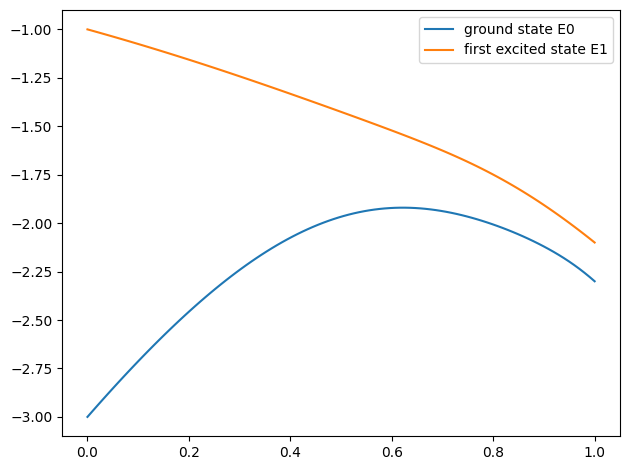

In [ ]:
E0, E1 = plot_results()

In [82]:
energy_gap = np.sum((np.dot(-1, E0), E1), axis = 0)

In [95]:
time = 0
steps = 100
for i in range(steps):
    x = E1[i] - E0[i]
    time += 1/(energy_gap[i] * energy_gap[i])
time /=steps

print("T_aqc: ", time)

T_aqc:  7.417416691813838


## Task2

In [105]:
def plot_results2(start, stop):
    lam = np.linspace(start,stop,100)
    sz_0_exp = []
    sz_1_exp = []
    sz_2_exp = []
    for i in lam:
        _, vecs = np.linalg.eigh(hamiltonian(i))
        psi_gs = vecs[:, 0]

        sz_0_exp.append(np.real(np.vdot(psi_gs, sz[0]@ psi_gs)))
        sz_1_exp.append(np.real(np.vdot(psi_gs, sz[1]@ psi_gs)))
        sz_2_exp.append(np.real(np.vdot(psi_gs, sz[2]@ psi_gs)))

    plt.plot(lam, sz_0_exp, label = 'sz_0_exp')
    plt.plot(lam, sz_1_exp, label = 'sz_1_exp')
    plt.plot(lam, sz_2_exp, label = 'sz_2_exp')
    plt.legend()
    plt.tight_layout()


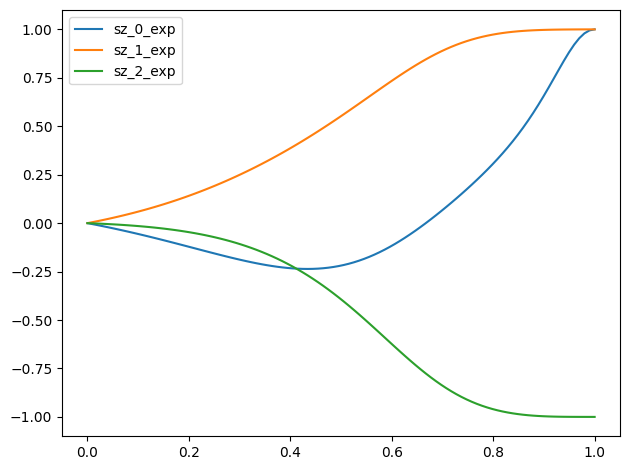

In [106]:
plot_results2(0,1)